In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv(r"data/processed/shopping_cleaned.csv")

print(df.shape)
print(df.head())
print(df.dtypes)

(3158, 13)
    Age Gender Item Purchased  Purchase Amount (USD)    Location Size  \
0  31.0   Male       Leggings              24.231704      Nevada    M   
1  38.0   Male     Sunglasses              36.545487      Oregon    S   
2  26.0   Male       Leggings              23.595139      Nevada   XL   
3  43.0   Male          Dress              34.079015  California    M   
4  29.0   Male         Shorts              23.796439   Minnesota    M   

         Color  Season Review Rating Shipping Type Promo Code Used  \
0  Terra cotta  Winter       Present      Standard              No   
1    Aubergine  Summer       Missing      Standard              No   
2        Brown  Winter       Missing      Standard              No   
3  Terra cotta    Fall       Present      Standard              No   
4     Lavender  Summer       Present       Express              No   

   Previous Purchases Payment Method  
0                   0    Credit Card  
1                   0    Credit Card  
2           

In [10]:
#Question 1:  What are the most popular colors by season?
color_by_season = df.groupby(['Season', 'Color']).size().reset_index(name='Count')
top_3_colors = color_by_season.sort_values(['Season', 'Count'], ascending=[True, False]).groupby('Season').head(3)

print(top_3_colors.to_string(index=False))

Season        Color  Count
  Fall        Brown     97
  Fall Burnt orange     93
  Fall  Terra cotta     91
Spring    Baby blue     69
Spring        White     63
Spring     Lavender     55
Summer     Lavender    102
Summer Lemon yellow     98
Summer    Baby blue     84
Winter        Black    124
Winter Burnt orange    112
Winter    Aubergine    111


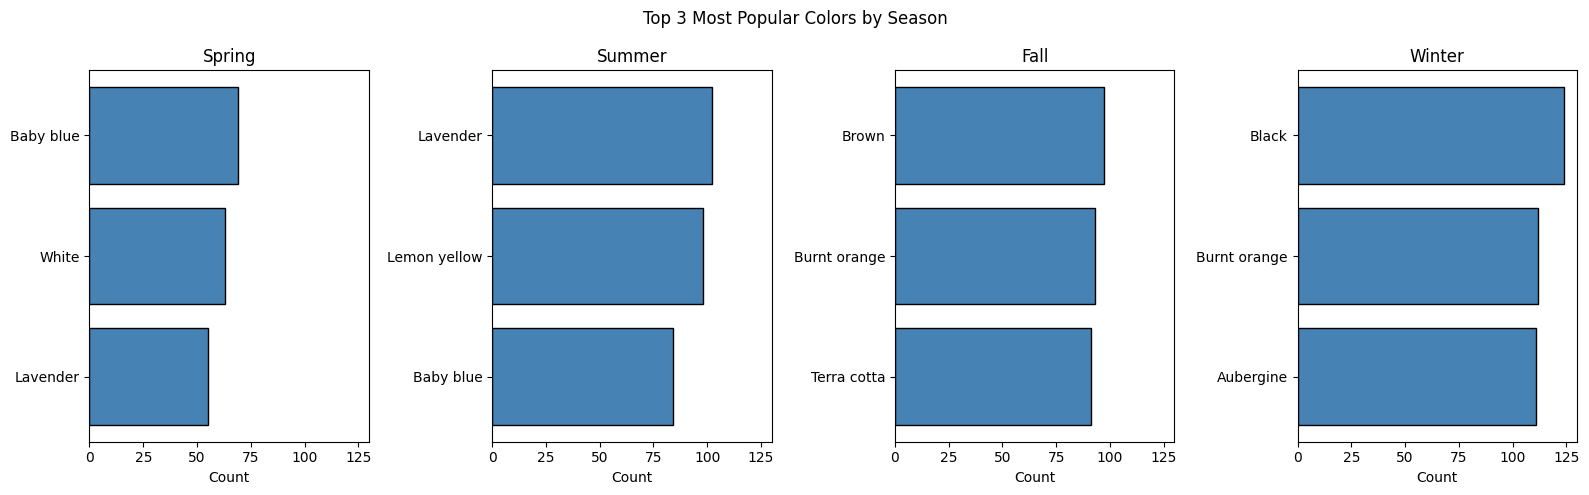

In [12]:
#Color by Season Chart
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, season in enumerate(season_order):
    season_data = top_3_colors[top_3_colors['Season'] == season].sort_values('Count')
    axes[i].barh(season_data['Color'], season_data['Count'], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{season}')
    axes[i].set_xlabel('Count')
    axes[i].set_xlim(0, 130) 

plt.suptitle('Top 3 Most Popular Colors by Season')
plt.tight_layout()
plt.show()

In [13]:
# Question 2: What is the most popular clothing item by season?
item_by_season = df.groupby(['Season', 'Item Purchased']).size().reset_index(name='Count')
top_3_items = item_by_season.sort_values(['Season', 'Count'], ascending=[True, False]).groupby('Season').head(3)

print(top_3_items.to_string(index=False))

Season Item Purchased  Count
  Fall       Backpack     72
  Fall        Sweater     72
  Fall          Socks     71
Spring  Running Shoes     89
Spring     Sunglasses     80
Spring        T-shirt     80
Summer         Shorts    152
Summer     Sunglasses    135
Summer  Running Shoes    134
Winter       Leggings    118
Winter       Backpack    113
Winter        Sweater    113


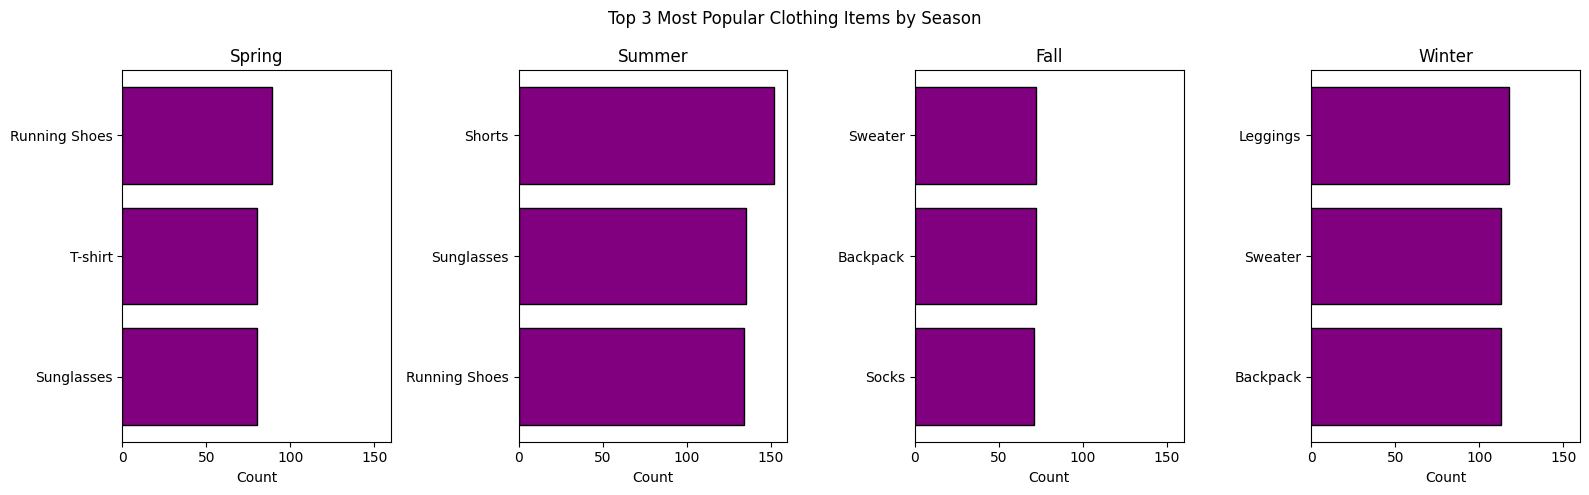

In [15]:
# Question 2 Chart: Most Popular Clothing Item by Season
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, season in enumerate(season_order):
    season_data = top_3_items[top_3_items['Season'] == season].sort_values('Count')
    axes[i].barh(season_data['Item Purchased'], season_data['Count'], color='purple', edgecolor='black')
    axes[i].set_title(f'{season}')
    axes[i].set_xlabel('Count')
    axes[i].set_xlim(0, 160)

plt.suptitle('Top 3 Most Popular Clothing Items by Season')
plt.tight_layout()
plt.show()

In [17]:
# Question 3: What is the effect of promo codes on purchase amounts?
promo_effect = df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean().reset_index()
promo_effect.columns = ['Promo Code Used', 'Average Purchase (USD)']

print(promo_effect.to_string(index=False))

Promo Code Used  Average Purchase (USD)
             No               30.155751
            Yes               50.067480


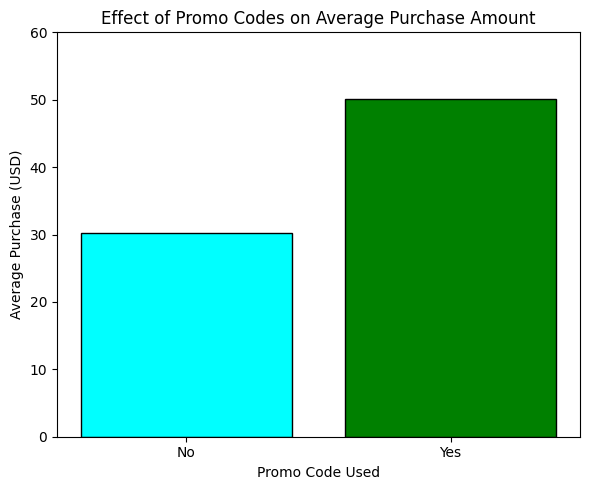

In [25]:
# Question 3 Chart: Effect of Promo Codes on Purchase Amount
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(promo_effect['Promo Code Used'], promo_effect['Average Purchase (USD)'],
       color=['aqua', 'green'], edgecolor='black')
ax.set_title('Effect of Promo Codes on Average Purchase Amount')
ax.set_xlabel('Promo Code Used')
ax.set_ylabel('Average Purchase (USD)')
ax.set_ylim(0,60)

plt.tight_layout()
plt.show()

In [21]:
# Question 4: When do users leave a review?
review_counts = df.groupby('Review Rating').size().reset_index(name='Count')

print(review_counts.to_string(index=False))

Review Rating  Count
      Missing   2020
      Present   1138


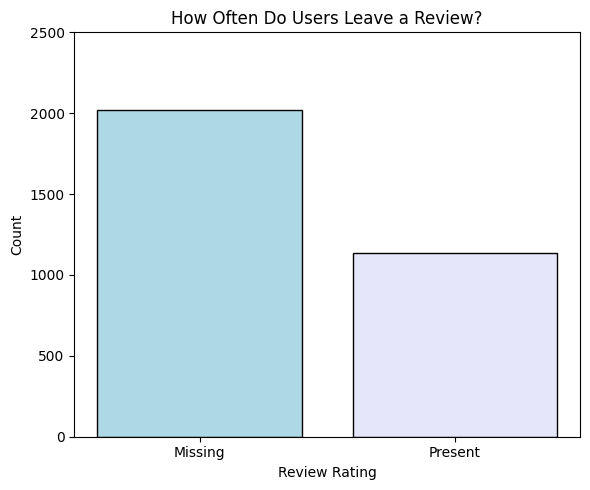

In [24]:
# Question 4 Chart: When do users leave a review?
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(review_counts['Review Rating'], review_counts['Count'],
       color=['lightblue', 'lavender'], edgecolor='black')
ax.set_title('How Often Do Users Leave a Review?')
ax.set_xlabel('Review Rating')
ax.set_ylabel('Count')
ax.set_ylim(0, 2500)

plt.tight_layout()
plt.show()

## Findings
**Question 1: Most Popular Colors by Season**
- Fall favors warm earth tones: Brown (97), Burnt Orange (93), Terra Cotta (91)
- Spring favors cool/light colors: Baby Blue (69), White (63), Lavender (55)
- Summer favors bright colors: Lavendar (102), Lemon Yellow(98), Baby Blue (84)
- Winter favors dark/bold colors: Black(124), Burnt Orange (112), Aubergine (111)

**Question 2: Most Popular Clothing Items by Season**
- Fall: Backpack & Sweater tied at (72), Socks (71)
- Spring: Running Shoes (89), Sunglasses & T-shirt tied (80)
-  Summer: Shorts (152), Sunglasses (135), Running Shoes (134)
- Winter: Leggings (118), Backpack & Sweater tied (113)

** Question 3: Effect of Promo Codes on Purchase Amount**
- Customers without promo codes spent an average of $30.16
- Customers with promo codes spent an average of $50.07
- Promo codes are associated with a $19.91 increase in spending

** Question 4: When Do Users Leave a Review**
- Only 1,138 out of 3,158 customers left a review (36%)
- 2,020 customers did not leave a reivew (64%)